<a href="https://colab.research.google.com/github/smosharof/Resume.Walkthrough/blob/main/KYC_Analytics_Proxy_with_Credit_Scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest

# 1. Load the dataset
#df = pd.read_csv("bank.csv")



# Download the dataset
path = kagglehub.dataset_download("kapturovalexander/bank-credit-scoring")

# Get the list of files in the directory
files = os.listdir(path)

# Assuming the CSV file is the only file or one of the CSV files
csv_files = [file for file in files if file.endswith('.csv')]

if len(csv_files) > 0:
    csv_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(csv_path)
else:
    print("No CSV files found in the downloaded dataset.")
    df = None

if df is not None:
    print("Dataset loaded successfully.")
    print(df.head())  # Display the first few rows
    print(df.info())  # Display dataset information
else:
    print("Dataset loading failed. 'df' not created.")

Dataset loaded successfully.
  age;"job";"marital";"education";"default";"balance";"housing";"loan";"contact";"day";"month";"duration";"campaign";"pdays";"previous";"poutcome";"y"
0  30;"unemployed";"married";"primary";"no";1787;...                                                                                                  
1  33;"services";"married";"secondary";"no";4789;...                                                                                                  
2  35;"management";"single";"tertiary";"no";1350;...                                                                                                  
3  30;"management";"married";"tertiary";"no";1476...                                                                                                  
4  59;"blue-collar";"married";"secondary";"no";0;...                                                                                                  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 1 columns):
 #   Column                                                                                                                                                Non-Null Count  Dtype 
---  ------                                                                                                                                                --------------  ----- 
 0   age;"job";"marital";"education";"default";"balance";"housing";"loan";"contact";"day";"month";"duration";"campaign";"pdays";"previous";"poutcome";"y"  4521 non-null   object
dtypes: object(1)
memory usage: 35.4+ KB
None

--- Summary Statistics ---
       age;"job";"marital";"education";"default";"balance";"housing";"loan";"contact";"day";"month";"duration";"campaign";"pdays";"previous";"poutcome";"y"
count                                                4521                                             

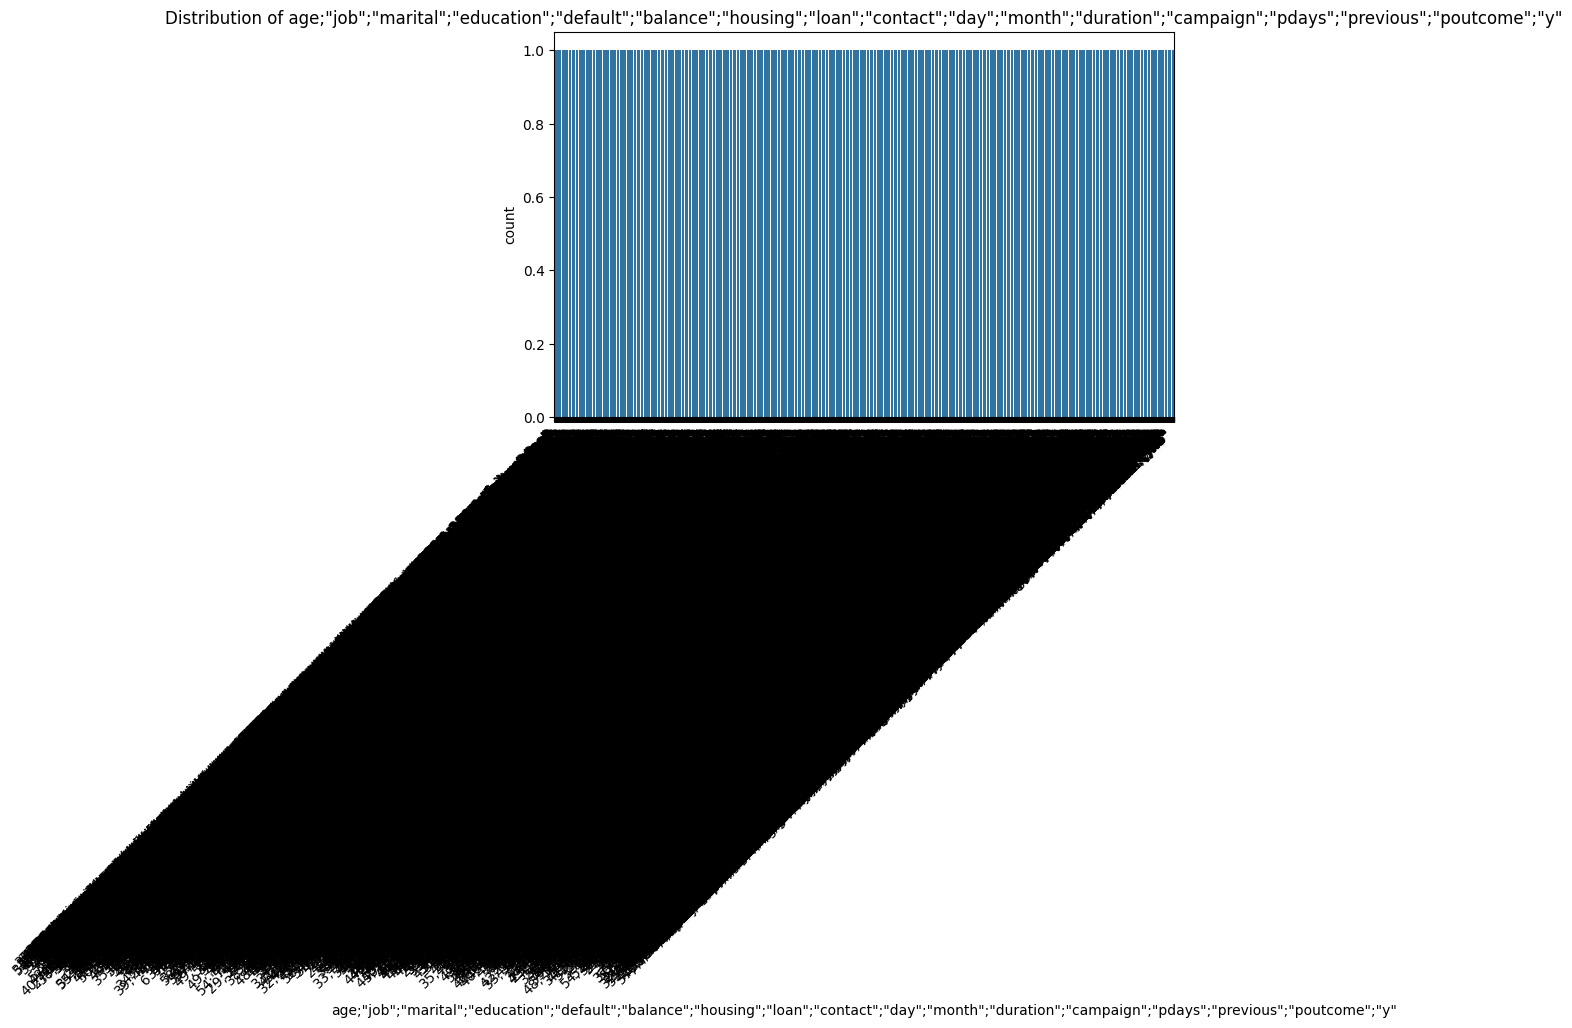

In [12]:

# 2. Exploratory Data Analysis (EDA)
def perform_eda(df):
    """Performs exploratory data analysis on the dataset."""

    print("--- Dataset Information ---")
    print(df.info())

    print("\n--- Summary Statistics ---")
    print(df.describe())

    print("\n--- Missing Values ---")
    print(df.isnull().sum())

    # Visualize class distribution (if 'y' exists, assuming it's the target)
    if 'y' in df.columns:
        plt.figure(figsize=(8, 5))
        ax = sns.countplot(x='y', data=df)
        plt.title('Distribution of Target Variable (y)')
        for p in ax.patches:
            ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha='center', va='bottom', fontsize=10)
        plt.show()
    else:
        print("Warning: 'y' column not found. Skipping class distribution visualization.")

    # Visualize correlations (only for numerical columns)
    numerical_df = df.select_dtypes(include=np.number)
    if not numerical_df.empty:
        plt.figure(figsize=(12, 10))
        sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm')
        plt.title('Correlation Matrix (Numerical Features)')
        plt.show()
    else:
        print("Warning: No numerical columns found. Skipping correlation matrix visualization.")

    # Visualize distributions of a few key features (adjust as needed)
    if 'age' in df.columns:
        plt.figure(figsize=(8, 5))
        sns.histplot(df['age'], kde=True)
        plt.title('Distribution of Age')
        plt.show()

    if 'balance' in df.columns:
        plt.figure(figsize=(8, 5))
        sns.histplot(df['balance'], kde=True)
        plt.title('Distribution of Balance')
        plt.show()

    if 'duration' in df.columns:
        plt.figure(figsize=(8, 5))
        sns.histplot(df['duration'], kde=True)
        plt.title('Distribution of Duration')
        plt.show()

    # Visualize distributions of categorical features (if any)
    categorical_cols = [col for col in df.columns if df[col].dtype == 'object']
    for col in categorical_cols:
        plt.figure(figsize=(8, 5))
        sns.countplot(x=col, data=df)
        plt.title(f'Distribution of {col}')
        plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
        plt.show()

    # Add more visualizations as needed (e.g., boxplots for outliers, categorical distributions)

perform_eda(df)


In [27]:
# 3. Feature Selection/Engineering
# Identify features relevant for risk classification. Adapt this based on your understanding of the data.
# 'y' is assumed to be the target variable (High/Medium/Low risk).  If it's not, change it.
if 'y' in df.columns:
    target = 'y'
    features = [col for col in df.columns if col != target]  # Use all other columns as features

    # Handle categorical features
    categorical_features = [col for col in features if df[col].dtype == 'object']
    df = pd.get_dummies(df, columns=categorical_features, drop_first=True) # drop_first to avoid multicollinearity
    features = [col for col in df.columns if col != target] # Update features after one-hot encoding

    # 4. Data Preprocessing
    # Impute missing values (if any) - Check df.isnull().sum() in EDA!
    imputer = SimpleImputer(strategy='most_frequent') #  Use 'most_frequent' for categorical, 'mean' or 'median' for numerical if appropriate
    df[features] = imputer.fit_transform(df[features])

    # Scale numerical features (if any)
    numerical_features = [col for col in features if df[col].dtype != 'object'] # Numerical columns after encoding
    if numerical_features:
        scaler = StandardScaler()
        df[numerical_features] = scaler.fit_transform(df[numerical_features])

    # 5. Split Data
    X = df[features]
    y = df[target]
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

    # 6. Build and Train XGBoost Model
    xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', objective='multi:softmax')  # Use 'mlogloss' for multiclass, specify objective
    xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], early_stopping_rounds=10, verbose=False)

    # 7. Evaluate Model
    def evaluate_model(model, X_test, y_test):
        """Evaluates the model and prints metrics."""

        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)  # Probabilities for each class

        print("\n--- Classification Report ---")
        print(classification_report(y_test, y_pred))

        print("\n--- Confusion Matrix ---")
        print(confusion_matrix(y_test, y_pred))

        # AUC for multiclass (One-vs-Rest)
        from sklearn.preprocessing import LabelBinarizer
        from sklearn.metrics import roc_auc_score

        label_binarizer = LabelBinarizer().fit(y_test)
        y_one_hot = label_binarizer.transform(y_test)
        #y_pred_one_hot = label_binarizer.transform(y_pred) # Removed: not used

        try:
            auc_ovr = roc_auc_score(y_one_hot, y_pred_proba, multi_class="ovr", average="macro")
            print(f"\n--- AUC Score (OvR): {auc_ovr:.4f} ---")
        except ValueError as e:
            print(f"\n--- AUC Score (OvR) not calculated: {e} ---")

        # ROC Curve (example for one class, adjust as needed)
        n_classes = len(model.classes_)
        if n_classes <= 2:  # Binary classification
            fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])
            plt.figure(figsize=(8, 5))
            plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_pred_proba[:, 1]):.4f}")
            plt.plot([0, 1], [0, 1], linestyle='--')
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title('ROC Curve')
            plt.legend()
            plt.show()
        else:
            print("\nROC Curve not plotted for multiclass classification.")

    evaluate_model(xgb_model, X_test, y_test)

    # 8. Feature Importance (Optional)
    def plot_feature_importance(model, features):
        """Plots feature importance."""

        importances = model.feature_importances_
        feature_importance = pd.DataFrame({'Feature': features, 'Importance': importances})
        feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

        plt.figure(figsize=(10, 6))
        plt.barh(feature_importance['Feature'], feature_importance['Importance'])
        plt.title('Feature Importance')
        plt.xlabel('Importance')
        plt.ylabel('Feature')
        plt.show()

    if features:  # Only plot if there are features to plot
        plot_feature_importance(xgb_model, features)

    else:
      print("Error: Target column 'y' not found in the dataset. Please check column names and adjust the code accordingly.")